# Struktury sufiksowe, algorytm Ukkonena, porównanie różnych metod znajdywania wzora w tekście


## Zadania

### Zadanie 1: Implementacja Algorytmu Ukkonena
Zaimplementuj algorytm Ukkonena do konstruowania drzewa sufiksów. Twoja implementacja powinna zawierać trzy kluczowe optymalizacje z algorytmu Ukkonena:

 - Technika skip/count
 - Reguła 3 (reguła łącza sufiksowego)
 - Technika wskaźnika końcowego

Przetestuj swoją implementację na różnych tekstach i wzorcach, aby upewnić się, że działa poprawnie. Przeanalizuj i wyjaśnij złożoność czasową swojej implementacji.


### Zadanie 2: Rozszerzone Problemy z Najdłuższymi Wspólnymi Podciągami

Zaimplementuj funkcje rozwiązujące następujące problemy związane z najdłuższymi wspólnymi podciągami, wykorzystując struktury sufiksowe:

Dla każdej z tych funkcji:

 - Zaimplementuj rozwiązanie wykorzystujące odpowiednią strukturę sufiksową (drzewo sufiksów lub tablicę sufiksów)
 - Przeanalizuj złożoność czasową i pamięciową
 - Przetestuj na różnych zbiorach danych, w tym przypadkach brzegowych
 - Porównaj wydajność Twojego rozwiązania z podejściami wykorzystującymi inne algorytmy (np. programowanie dynamiczne)

Utwórz wykres porównujący czas wykonania algoritmu najdłuższego wspólnego podciągu dla dwóch ciągów znaków w zależności od długości ciągów, używając drzewa sufiksowego, tablicy sufiksów oraz dowolnego innego algorytmu.

Podpowiedź: Problem najdłuższego wspólnego podciągu dla wielu ciągów znaków jest znacznie trudniejszy niż dla dwóch ciągów. Zastanów się, jak można zmodyfikować podstawowy algorytm, aby uwzględnić większą liczbę ciągów. Dla problemu najdłuższego palindromicznego podciągu, rozważ, jak można wykorzystać właściwości palindromów w połączeniu ze strukturami sufiksowymi.



### Zadanie 3: Tablica Sufiksów vs. Drzewo Sufiksów

Zaimplementuj obie struktury danych - tablicę sufiksów i drzewo sufiksów - dla tego samego tekstu, a następnie porównaj ich zużycie pamięci i czas konstrukcji.

Przeanalizuj, jak te metryki skalują się wraz z rozmiarem tekstu, testując na tekstach o różnej długości (np. 100, 1000, 10000, 100000 znaków).

Ważne: Utwórz szczegółowe wykresy pokazujące:

 - Czas konstrukcji w zależności od rozmiaru tekstu
 - Zużycie pamięci w zależności od rozmiaru tekstu
 - Rozmiar (liczba elementów) w zależności od rozmiaru tekstu

Użyj odpowiednich skal i upewnij się, że wykresy wyraźnie ilustrują różnice w charakterystykach wydajności. Wyjaśnij, w jakich scenariuszach preferowałbyś tablice sufiksów zamiast drzew sufiksów i odwrotnie.


### Zadanie 4: Analiza Porównawcza Algorytmów Dopasowywania Wzorców (3 pkt)

Zaimplementuj następujące algorytmy dopasowywania wzorców (lub użyj tych, które zostały zaimplementowane w poprzednich laboratoriach):

 - Naiwny algorytm dopasowywania wzorców
 - Algorytm KMP (Knutha-Morrisa-Pratta)
 - Algorytm Boyer-Moore
 - Algorytm Rabin-Karp
 - Algorytm Aho-Corasick (dla wyszukiwania wielu wzorców jednocześnie)
 - Wyszukiwanie oparte na tablicy sufiksów
 - Wyszukiwanie oparte na drzewie sufiksów (z wykorzystaniem implementacji algorytmu Ukkonena)


Następnie stwórz funkcję, która porównuje ich wydajność.
Przetestuj algorytmy na tekstach o różnych rozmiarach i wzorcach o różnej długości.
Ważne: Utwórz szczegółowe porównania wizualne przy użyciu odpowiednich wykresów dla:

 - Czasu wykonania w zależności od rozmiaru tekstu
 - Zużycia pamięci w zależności od rozmiaru tekstu
 - Liczby porównań w zależności od rozmiaru tekstu
 - Czasu wykonania w zależności od długości wzorca

Użyj skal logarytmicznych tam, gdzie jest to odpowiednie, aby wyraźnie pokazać różnice między algorytmami. Wyjaśnij kompromisy między algorytmami na podstawie swoich wyników.


## Zadanie 1

### Teoria algorytmu Ukkonena


#### Algorytm Ukkonena – opis działania

Algorytm Ukkonena to wydajny algorytm do budowy drzewa sufiksowego dla napisu w czasie liniowym O(n). Kluczową cechą tej metody jest budowanie drzewa przyrostowo w każdej fazie, litera po literze, oraz zastosowanie trzech głównych optymalizacji:
Kluczowe pojęcia

    Drzewo sufiksowe: drzewo zawierające wszystkie sufiksy danego napisu jako ścieżki od korzenia do liścia.

    Faza (Phase): dodanie kolejnej litery do drzewa.

    Rozszerzenia (Extensions): dodanie wszystkich możliwych nowych sufiksów kończących się na nowej literze.

    Aktywny punkt (Active Point): określa miejsce, w którym algorytm aktualnie pracuje, składa się z:

        active_node

        active_edge

        active_length

Optymalizacje Ukkonena
1. Skip/Count

Zamiast przechodzić każdą literę krawędzi od początku, przechodzimy ją "skokowo" – jeśli długość krawędzi jest mniejsza niż active_length, przechodzimy do kolejnego węzła, aktualizując wskaźniki. Pozwala to uniknąć nieefektywnego porównywania liter.
2. Suffix Links (Reguła 2 i Reguła 3)

    Reguła 2: Gdy w danej fazie tworzymy nowy węzeł wewnętrzny, zapamiętujemy go jako last_new_node. Jeśli w następnej iteracji utworzony zostanie kolejny węzeł wewnętrzny, łączymy last_new_node z nowym węzłem za pomocą sufiksowego łącza (suffix_link).

    Reguła 3: Po zakończeniu rozszerzenia z węzła innego niż root, aktywny węzeł jest aktualizowany poprzez sufiksowe łącze. Jeśli takie łącze nie istnieje, przechodzimy do korzenia.

3. Wskaźnik końcowy (End Pointer)

Używany przy liściach – zamiast przypisywać im konkretny koniec (end = i), przypisujemy im wskaźnik do globalnego end, który rośnie wraz z kolejnymi fazami. Dzięki temu liście "same się aktualizują".
Złożoność obliczeniowa

    Czasowa: O(n) – każde rozszerzenie jest wykonywane w czasie stałym dzięki powyższym optymalizacjom.

    Pamięciowa: O(n) – z racji przechowywania każdego sufiksu i krawędzi.

Operacje na drzewie
Budowanie drzewa

Drzewo jest budowane w build_tree() – przetwarza się kolejne litery napisu i rozszerza istniejące ścieżki lub tworzy nowe. W każdej fazie wykonywane są wszystkie niezbędne rozszerzenia, zgodnie z regułami algorytmu.
Wyszukiwanie wzorca

Funkcja find_pattern(pattern) porusza się po drzewie zgodnie z literami wzorca. Jeżeli ścieżka pasująca do wzorca istnieje, odwiedzane są wszystkie liście z niej wychodzące (DFS) i zwracane są ich indeksy sufiksów jako miejsca wystąpienia wzorca.
Przykład

Dla napisu "banana", drzewo będzie zawierać ścieżki odpowiadające wszystkim sufiksom: "banana", "anana", "nana", "ana", "na", "a". Po dodaniu znaku $ otrzymujemy jednoznaczne rozróżnienie końców.

Wzorzec "ana" występuje w pozycjach 1 i 3.
Podsumowanie

Algorytm Ukkonena jest skomplikowany w implementacji, ale niezwykle wydajny w działaniu. Dzięki zastosowaniu sufiksowych łączy, optymalizacji skip/count i wskaźnika końcowego, uzyskujemy budowę drzewa w czasie liniowym względem długości tekstu.


### Implementacja

In [1]:
"""
Zaimplementuj algorytm Ukkonena do konstruowania drzewa sufiksów.

Twoja implementacja powinna zawierać trzy kluczowe optymalizacje z algorytmu Ukkonena:
- Technika skip/count
- Reguła 3 (reguła łącza sufiksowego)
- Technika wskaźnika końcowego
Przetestuj swoją implementację na różnych tekstach i wzorcach, aby upewnić się,
że działa poprawnie. Przeanalizuj i wyjaśnij złożoność czasową swojej implementacji.

"""

class Node:
  # End == None means, that the end is the current # variable
  def __init__(self, start = -1, end = None):
    self.children : dict[str, Node]= {}
    self.suffix_link = None
    self.start = start
    self.end = end
    self.suffix_index = -1
    
  def edge_length(self, position):
    if(self.end > position):
      return position - self.start + 1
    return self.end - self.start + 1


class SuffixTree:
  def __init__(self, text: str):
    """
    Construct a suffix tree for the given text using Ukkonen's algorithm.

    Args:
        text: The input text for which to build the suffix tree
    """
    self.text = text + "$"
    self.size = len(self.text)
    self.last_new_node = None
    self.root = Node()
    self.root.suffix_link = self.root
    
    # The "active point" variable
    self.active_node = self.root # node
    self.active_edge = -1 #character
    self.active_length = 0 #position
    
    # The amount of suffixes left to consider, given last letter is #
    self.remainder = 0
    
    self.build_tree()
    self.set_suffix_index(self.root, 0)
    
  # RULE 1
  # If after an insertion from the active node = root,
  # the active length is greater than 0, then:
  # -active node is not changed
  # -active length is decremented
  # -active edge is shifted right (to the first 
  #  character of the next suffix we must insert)
  
  # RULE 2
  # If we create a new internal node OR make an inserter 
  # from an internal node, and this is not the first SUCH 
  # internal node at current step, then we link the previous
  # SUCH node with THIS one through a suffix link.

  # RULE 3
  # After an insert from the active node which is not the root node,
  # we must follow the suffix link and set the active node to the 
  # node it points to. If there is no a suffix link, 
  # set the active node to the root node. Either way, active
  # edge and active length stay unchanged.


     
  def build_tree(self):
    """
    Build the suffix tree using Ukkonen's algorithm.
    """

    # i == # varianle
    for i in range(self.size):
      
      # Increment the amount of suffixes needed to be added
      self.remainder += 1
      self.last_new_node : Node | None = None
      
      # Add all suffixes
      while(self.remainder > 0):
        # Guard in the case of inserting the entirety of previous
        # suffixes (or starting) and having to start again
        # from the # suffix letter
        if(self.active_length == 0):
          self.active_edge = i
        
        edge_character = self.text[self.active_edge]
        
        # if there IS NOT an outgoing edge labelled with edge_character
        if(edge_character not in self.active_node.children):
          # if there is no outgoing edge of the character at the current i
          # create a node of that character ending on #
          
          self.active_node.children[edge_character] = Node(start=i, end = self.size-1)
          
          # RULE 2
          if(self.last_new_node is not None):
            self.last_new_node.suffix_link = self.active_node
            self.last_new_node = None
        
        # if there IS an outgoing edge labelled with edge_character
        else:
          # By getting next_node we are considering the edge
          # between current_node and next_node
          # when it comes to starts and ends
          next_node: Node = self.active_node.children[edge_character]
          # SKIP-COUNT STEP
          # if the edge's label is shorter than current length,
          # simply skip it and continue on with next labels
          
          # active_node = X
          # active_length = 4
          # active_edge = 'a' (but its numeric, we use numbers to represent letters)
          #    ab       cdef 
          # X -----> X' -----> X''
          # length = 2
          # length < active_length we wish to skip it then, so:
          # active_edge = 'c' (but numerically)
          # active_length = 2 (we reduce it accordingly)
          # active_node = X'
          
          # From that point, we may continue our logic as before
          
          length = next_node.edge_length(i)
          if(self.active_length >= length):
            self.active_edge += length
            self.active_length -= length
            self.active_node = next_node
            continue
          
          # if current character is part of the edge 
          # (between next_nodes start and end)
          if(self.text[next_node.start + self.active_length] == self.text[i]):
            # RULE 2
            # if a new internal node was created in a previous iteration of the same phase
            # phase -> loop for given remainder
            if(self.last_new_node is not None and self.active_node != self.root):
              self.last_new_node.suffix_link = self.active_node
              self.last_new_node = None
            
            self.active_length += 1
            # Exit current phase
            break
        
          # if the current character is not on the edge
          # and none of the above happened, we have to split the node
          
          # Get the position of current character
          split_position = next_node.start + self.active_length - 1
          # And do this funky move
          # Imagine we are trying to insert 'abcd' suffix into the below example
          #    ab       cabx
          # X ----> X' ----> X''
          # we would turn that into
          #    ab        c        abxd
          # X ----> X' ----> X'' ----> X''''
          #                  | d
          #                  v
          #                  X'''
          
          # This is inserting X'' into X'
          split_node = Node(next_node.start, split_position)
          self.active_node.children[edge_character] = split_node
          # This is the  X'' to X'''
          split_node.children[self.text[i]] = Node(start=i, end = self.size-1)
          # This is updating the old X'' into X'''' (so X'' -> X'''' edge)
          next_node.start += self.active_length
          split_node.children[self.text[next_node.start]] = next_node 
          
          # RULE 2
          if(self.last_new_node is not None):
            self.last_new_node.suffix_link = split_node
            
          self.last_new_node = split_node
        
        self.remainder -= 1
        
        # RULE 1
        if(self.active_node == self.root and self.active_length > 0):
          self.active_length -= 1
          self.active_edge = i - self.remainder + 1
        
        # RULE 3
        elif(self.active_node != self.root):
          self.active_node = (
            self.active_node.suffix_link if 
            self.active_node.suffix_link is not None else 
            self.root
          )
          
  def set_suffix_index(self, node: Node, label_length):
    if not node.children:
        node.suffix_index = self.size - label_length
        # print(node.start, node.end, node.suffix_index)
    else:
        for child in node.children.values():
            edge_len = child.end - child.start + 1
            self.set_suffix_index(child, label_length + edge_len)

  
  def find_pattern(self, pattern: str) -> list[int]:
    """
    Find all occurrences of the pattern in the text.

    Args:
        pattern: The pattern to search for

    Returns:
        A list of positions where the pattern occurs in the text
    """
    m = len(pattern)
    current = self.root
    
    i = 0
    while(i < m):
      c = pattern[i]
      # Cannot continue (or even start) iterating through pattern given
      # the tree
      if(c not in current.children):
        return []
      child = current.children[c]
      child_length = child.end - child.start + 1
      proper_length = min(child_length, m - i)
      segment = self.text[child.start: child.start + proper_length]
      # Can continue with first char, but the rest does not match
      if pattern[i:i+proper_length] != segment:
        return []
      i += proper_length
      current = child
    
    # Collect results from leaves (suffix_index) through dfs
    result = []
    
    def dfs(node: Node):
      if node.suffix_index >= 0:
        result.append(node.suffix_index)
      for child in node.children.values():
        dfs(child)
        
    dfs(current)
    return sorted(result)

if __name__ == "__main__":
  def test_suffix_tree():
    cases = [
      {
        "text": "banana",
        "pattern": "ana",
        "expected": [1, 3]
      },
      {
        "text": "aaaaa",
        "pattern": "aaa",
        "expected": [0, 1, 2]
      },
      {
        "text": "abcd",
        "pattern": "bc",
        "expected": [1]
      },
      {
        "text": "mississippi",
        "pattern": "issi",
        "expected": [1, 4]
      },
      {
        "text": "abcdef",
        "pattern": "xyz",
        "expected": []
      },
      {
        "text": "x",
        "pattern": "x",
        "expected": [0]
      },
      {
        "text": "abcabcabc",
        "pattern": "abc",
        "expected": [0, 3, 6]
      },
      {
        "text": "test pattern test test pattern test",
        "pattern": "pattern",
        "expected": [5, 23]
      },
      {
        "text": "abababab",
        "pattern": "aba",
        "expected": [0, 2, 4]
      }
    ]
    
    all_passed = True

    for i, case in enumerate(cases):
      text, pattern, expected = case["text"], case["pattern"], case["expected"]
      tree = SuffixTree(text)
      result = sorted(tree.find_pattern(pattern))
      if result != expected:
        print(f"Test {i + 1} FAILED: text='{text}', pattern='{pattern}'")
        print(f"Expected: {expected}, Got: {result}")
        all_passed = False
      else:
        print(f"Test {i + 1} passed")
    
    if all_passed:
      print("ALL PASSED!")

  test_suffix_tree()


Test 1 passed
Test 2 passed
Test 3 passed
Test 4 passed
Test 5 passed
Test 6 passed
Test 7 passed
Test 8 passed
Test 9 passed
ALL PASSED!


## Zadanie 2

### Teoria tablic sufiksowych

### Najdłuższe wspólne i palindromiczne podciągi przy użyciu tablic sufiksów

Te rozwiązania są oparte na:

Konstrukcji tablicy sufiksów przy użyciu algorytmu podwajania

Konstrukcji tablicy LCP przy użyciu algorytmu Kasai

<!-- build_suffix_array(s: str) -> List[int] -->

Konstruuje tablicę sufiksów danego ciągu s przy użyciu techniki podwajania.
Tablica sufiksów to posortowana lista wszystkich sufiksów s według kolejności leksykograficznej, reprezentowana przez ich indeksy początkowe.

Złożoność czasowa: $ O(n \log_2 n ) $

Przykład:
Dla s = "banana" zwraca kolejność sufiksów, takich jak ["a", "ana", "anana", "banana", "na", "nana"].

build_lcp(s: str, sa: List[int]) -> List[int]

Konstruuje tablicę LCP dla ciągu s, biorąc pod uwagę jego tablicę sufiksów sa.
Tablica LCP przechowuje długości najdłuższych wspólnych prefiksów między kolejnymi sufiksami w tablicy sufiksów.

Złożoność czasowa: $ O(n) $

Przykład:
Dla s = "banana" i jego tablicy sufiksów, mogą zostać zwrócone wartości LCP takie jak [0, 1, 3, 0, 0, 2].

longest_common_substring(str1: str, str2: str) -> str

Znajduje najdłuższy wspólny podciąg między dwoma ciągami przy użyciu tablic sufiksów i LCP.
Jak to działa:

Łączy str1 + "#" + str2 + "$", aby utworzyć pojedynczy ciąg z unikalnymi separatorami.

Buduje tablice sufiksów i LCP.

Skanuje tablicę LCP w celu znalezienia maksymalnego LCP między sufiksami pochodzącymi z różnych ciągów.

Złożoność czasowa: $ O(n \log_2 n ) $

Przykład:
Dla str1 = "banana", str2 = "ananas" → zwraca "anana".

longest_common_substring_multiple(strings: List[str]) -> str

Znajduje najdłuższy wspólny podciąg wśród wielu ciągów przy użyciu uogólnionej tablicy sufiksów.
Kluczowe kroki:

Łączy wszystkie ciągi z unikalnymi znakami separatora spoza ASCII (np. chr(257), chr(258), ...).

Konstruuje tablice sufiksów i LCP na połączonym ciągu.

Używa przesuwanego okna nad tablicą sufiksów, aby znaleźć najdłuższy LCP, który pojawia się we wszystkich oryginalnych ciągach.

Przykład:
Dane wejściowe: ["ababc", "babca", "abcba"] → Dane wyjściowe: "abc"

longest_palindromic_substring(text: str) -> str

Znajduje najdłuższy palindromiczny podciąg w podanym tekście, przekształcając go w problem najdłuższego wspólnego podciągu.
Strategia:

Odwróć ciąg i połącz: text + "#" + reversed(text) + "$".

Buduj tablice sufiksów i LCP.

Szukaj najdłuższego wspólnego prefiksu między sufiksami z oryginalnej i odwróconej części, które tworzą prawidłowy palindrom.

Przykład:
Dla text = "babad" → zwraca "bab" lub "aba"

Przykład użycia

if __name__ == "__main__":
print(longest_common_substring("banana", "ananas")) # Dane wyjściowe: "anana"
print(longest_common_substring_multiple(["ababc", "babca", "abcba"])) # Dane wyjściowe: "abc"
print(longest_palindromic_substring("babad")) # Dane wyjściowe: "bab" lub "aba"

Notatki

Tablice sufiksów to potężne narzędzia do wydajnego rozwiązywania problemów z podciągami i wzorcami.

Algorytm Kasai jest używany do budowania tablic LCP w czasie liniowym.

Kod obsługuje przypadki brzegowe, takie jak puste ciągi lub brak wspólnych podciągów.

### Implementacja

In [4]:
from typing import List, Tuple


def build_suffix_array(s: str) -> List[int]:
    """
    Build the suffix array for string s using the doubling algorithm.

    Args:
        s: Input string

    Returns:
        A list SA of length len(s), where SA[i] is the starting index of the i-th smallest suffix of s.
    """
    n = len(s)
    # Initial ranking: rank[i] = ord(s[i])
    rank = [ord(c) for c in s]
    sa = list(range(n))
    tmp = [0] * n
    k = 1

    def compare(i: int, j: int) -> bool:
        # Compare pair (rank[i], rank[i+k]) vs (rank[j], rank[j+k]), where rank[x] = -1 if x >= n
        if rank[i] != rank[j]:
            return rank[i] < rank[j]
        ri = rank[i + k] if i + k < n else -1
        rj = rank[j + k] if j + k < n else -1
        return ri < rj

    while k < n:
        # Sort SA by (rank[i], rank[i+k]) using the compare function
        sa.sort(key=lambda x: (rank[x], rank[x + k] if x + k < n else -1))
        # Build temporary array tmp with new ranks
        tmp[sa[0]] = 0
        for i in range(1, n):
            tmp[sa[i]] = tmp[sa[i - 1]] + (1 if compare(sa[i - 1], sa[i]) else 0)
        rank[:] = tmp[:]
        k <<= 1
        if rank[sa[-1]] == n - 1:
            break

    return sa


def build_lcp(s: str, sa: List[int]) -> List[int]:
    """
    Build the LCP array for string s given its suffix array sa using Kasai's algorithm.

    Args:
        s: Input string
        sa: Suffix array of s

    Returns:
        LCP array where lcp[i] = LCP(sa[i], sa[i-1]) for i in [1..n-1], and lcp[0] = 0.
    """
    n = len(s)
    rank = [0] * n
    for i in range(n):
        rank[sa[i]] = i

    lcp = [0] * n
    h = 0
    for i in range(n):
        if rank[i] == 0:
            lcp[0] = 0
            continue
        j = sa[rank[i] - 1]
        # Compute LCP between suffixes at i and j
        while i + h < n and j + h < n and s[i + h] == s[j + h]:
            h += 1
        lcp[rank[i]] = h
        if h > 0:
            h -= 1
    return lcp


def longest_common_substring(str1: str, str2: str) -> str:
    """
    Find the longest common substring of two strings using a suffix array.

    Args:
        str1: First string
        str2: Second string

    Returns:
        The longest common substring
    """
    # Concatenate with unique separators
    sep1 = "#"
    sep2 = "$"
    combined = str1 + sep1 + str2 + sep2
    n1 = len(str1)
    n2 = len(str2)
    n = len(combined)

    # Build suffix array and LCP array
    sa = build_suffix_array(combined)
    lcp = build_lcp(combined, sa)

    max_len = 0
    pos = 0
    for i in range(1, n):
        i1 = sa[i]
        i2 = sa[i - 1]
        # Check if the two suffixes originate from different input strings
        if (i1 < n1 and i2 > n1) or (i1 > n1 and i2 < n1):
            if lcp[i] > max_len:
                max_len = lcp[i]
                pos = sa[i]

    # Extract longest common substring
    longest_substring = combined[pos : pos + max_len]
    return longest_substring


def longest_common_substring_multiple(strings: List[str]) -> str:
    """
    Find the longest common substring among multiple strings using a generalized suffix array.

    Args:
        strings: List of input strings

    Returns:
        The longest common substring that appears in all strings
    """
    # Concatenate all strings with unique separators
    # Use ASCII values starting from 1, 2, ..., which do not appear in any string.
    # We'll map each string to an integer ID [0..k-1].
    k = len(strings)
    if k == 0:
        return ""
    if k == 1:
        return strings[0]

    # Build combined string
    combined = []
    origin = []
    sep_ord = 1
    for idx, s in enumerate(strings):
        for c in s:
            combined.append(c)
            origin.append(idx)
        combined.append(chr(256 + sep_ord))  # Unique separator beyond standard ASCII
        origin.append(-1)
        sep_ord += 1

    combined_str = "".join(combined)
    n = len(combined_str)

    # Build suffix array and LCP
    sa = build_suffix_array(combined_str)
    lcp = build_lcp(combined_str, sa)

    # Sliding window over SA to find interval containing at least one suffix from each origin
    # Use two pointers and a counter array
    result_len = 0
    result_pos = 0

    from collections import Counter

    count = Counter()
    total_in_window = 0
    left = 0

    def get_origin(i: int) -> int:
        return origin[i]

    for right in range(n):
        orig_r = get_origin(sa[right])
        if orig_r != -1:
            count[orig_r] += 1
            if count[orig_r] == 1:
                total_in_window += 1

        # If window includes all k origins, try to shrink from left
        while total_in_window == k and left <= right:
            # Compute minimum LCP in [left+1..right]
            if left < right:
                min_lcp = min(lcp[left + 1 : right + 1])
                if min_lcp > result_len:
                    result_len = min_lcp
                    result_pos = sa[right]
            # Shrink window from left
            orig_l = get_origin(sa[left])
            if orig_l != -1:
                count[orig_l] -= 1
                if count[orig_l] == 0:
                    total_in_window -= 1
            left += 1

    if result_len == 0:
        return ""
    return combined_str[result_pos : result_pos + result_len]


def longest_palindromic_substring(text: str) -> str:
    """
    Find the longest palindromic substring in a given text using suffix array.

    Args:
        text: Input text

    Returns:
        The longest palindromic substring
    """
    n = len(text)
    if n == 0:
        return ""

    # Create a string: T + '#' + reverse(T) + '$'
    rev = text[::-1]
    sep = "#"
    end = "$"
    combined = text + sep + rev + end

    # Build suffix array and LCP
    sa = build_suffix_array(combined)
    lcp = build_lcp(combined, sa)
    total_len = len(combined)

    max_len = 0
    pos = 0

    for i in range(1, total_len):
        i1 = sa[i]
        i2 = sa[i - 1]
        # Check that one suffix comes from the original text part, the other from the reversed part
        if (i1 < n and i2 > n) or (i1 > n and i2 < n):
            # Potential palindrome length is lcp[i]
            length = lcp[i]
            # Identify starting positions in original text
            if i1 < n:
                start1 = i1
                start2 = i2 - (n + 1)  # adjust index in reversed part
            else:
                start1 = i2
                start2 = i1 - (n + 1)
            # Check if they correspond to a palindrome:
            # In original string, the substring starting at start1 of length `length`
            # should match the reverse substring starting at (n - 1 - start2 - (length - 1)).
            # Equivalently, start1 + length - 1 == n - 1 - start2
            if start1 + length - 1 == n - 1 - start2:
                if length > max_len:
                    max_len = length
                    pos = start1

    if max_len == 0:
        # Every single character is a palindrome
        return text[0]
    return text[pos : pos + max_len]


# Example usage (for quick sanity checks):
if __name__ == "__main__":
    # Two-string LCS test
    s1 = "banana"
    s2 = "ananas"
    print(f"LCS of two strings {s1} {s2}: {longest_common_substring(s1, s2)}")  # Expected "anana" or "anana"

    # Multiple-string LCS test
    strs = ["ababc", "babca", "abcba"]
    print(f"LCS of multiple strings: {strs}, {longest_common_substring_multiple(strs)}")  # Expected "abc"

    # Longest palindromic substring test
    t = "babad"
    print("Longest palindromic substring:", longest_palindromic_substring(t))  # Expected "bab" or "aba"


LCS of two strings banana ananas: anana
LCS of multiple strings: ['ababc', 'babca', 'abcba'], abc
Longest palindromic substring: aba


## Zadanie 3

### Porównanie teoretyczne


### Porównanie

Suffix Array vs Suffix Tree Comparison

Example test with text: 'banana'
Suffix Array:
  Construction time: 274.47 ms
  Memory usage: 0.72 KB
  Size: 12 elements
Suffix Tree:
  Construction time: 281.90 ms
  Memory usage: 4.40 KB
  Size: 11 nodes

Ratios (Suffix Tree / Suffix Array):
  Time: 1.03x
  Memory: 6.13x

Running comprehensive benchmark...
Running comprehensive benchmark...

Testing random texts:
✓ SA: 281.8ms, ST: 258.3ms
✓ SA: 256.0ms, ST: 247.8ms
✓ SA: 225.5ms, ST: 259.7ms
✓ SA: 277.3ms, ST: 255.1ms
✓ SA: 273.1ms, ST: 270.6ms
✓ SA: 304.1ms, ST: 357.9ms
✓ SA: 305.5ms, ST: 389.0ms

Testing repetitive texts:
✓ SA: 359.4ms, ST: 332.0ms
✓ SA: 308.0ms, ST: 328.8ms
✓ SA: 276.7ms, ST: 269.8ms
✓ SA: 278.0ms, ST: 285.4ms
✓ SA: 304.4ms, ST: 264.0ms
✓ SA: 354.7ms, ST: 359.2ms
✗ Error: maximum recursion depth exceeded while calling a Python object

Testing worst_case texts:
✓ SA: 319.8ms, ST: 276.9ms
✓ SA: 220.5ms, ST: 271.8ms
✓ SA: 263.2ms, ST: 251.2ms
✓ SA: 252.9ms, ST: 242.7ms
✓ SA: 

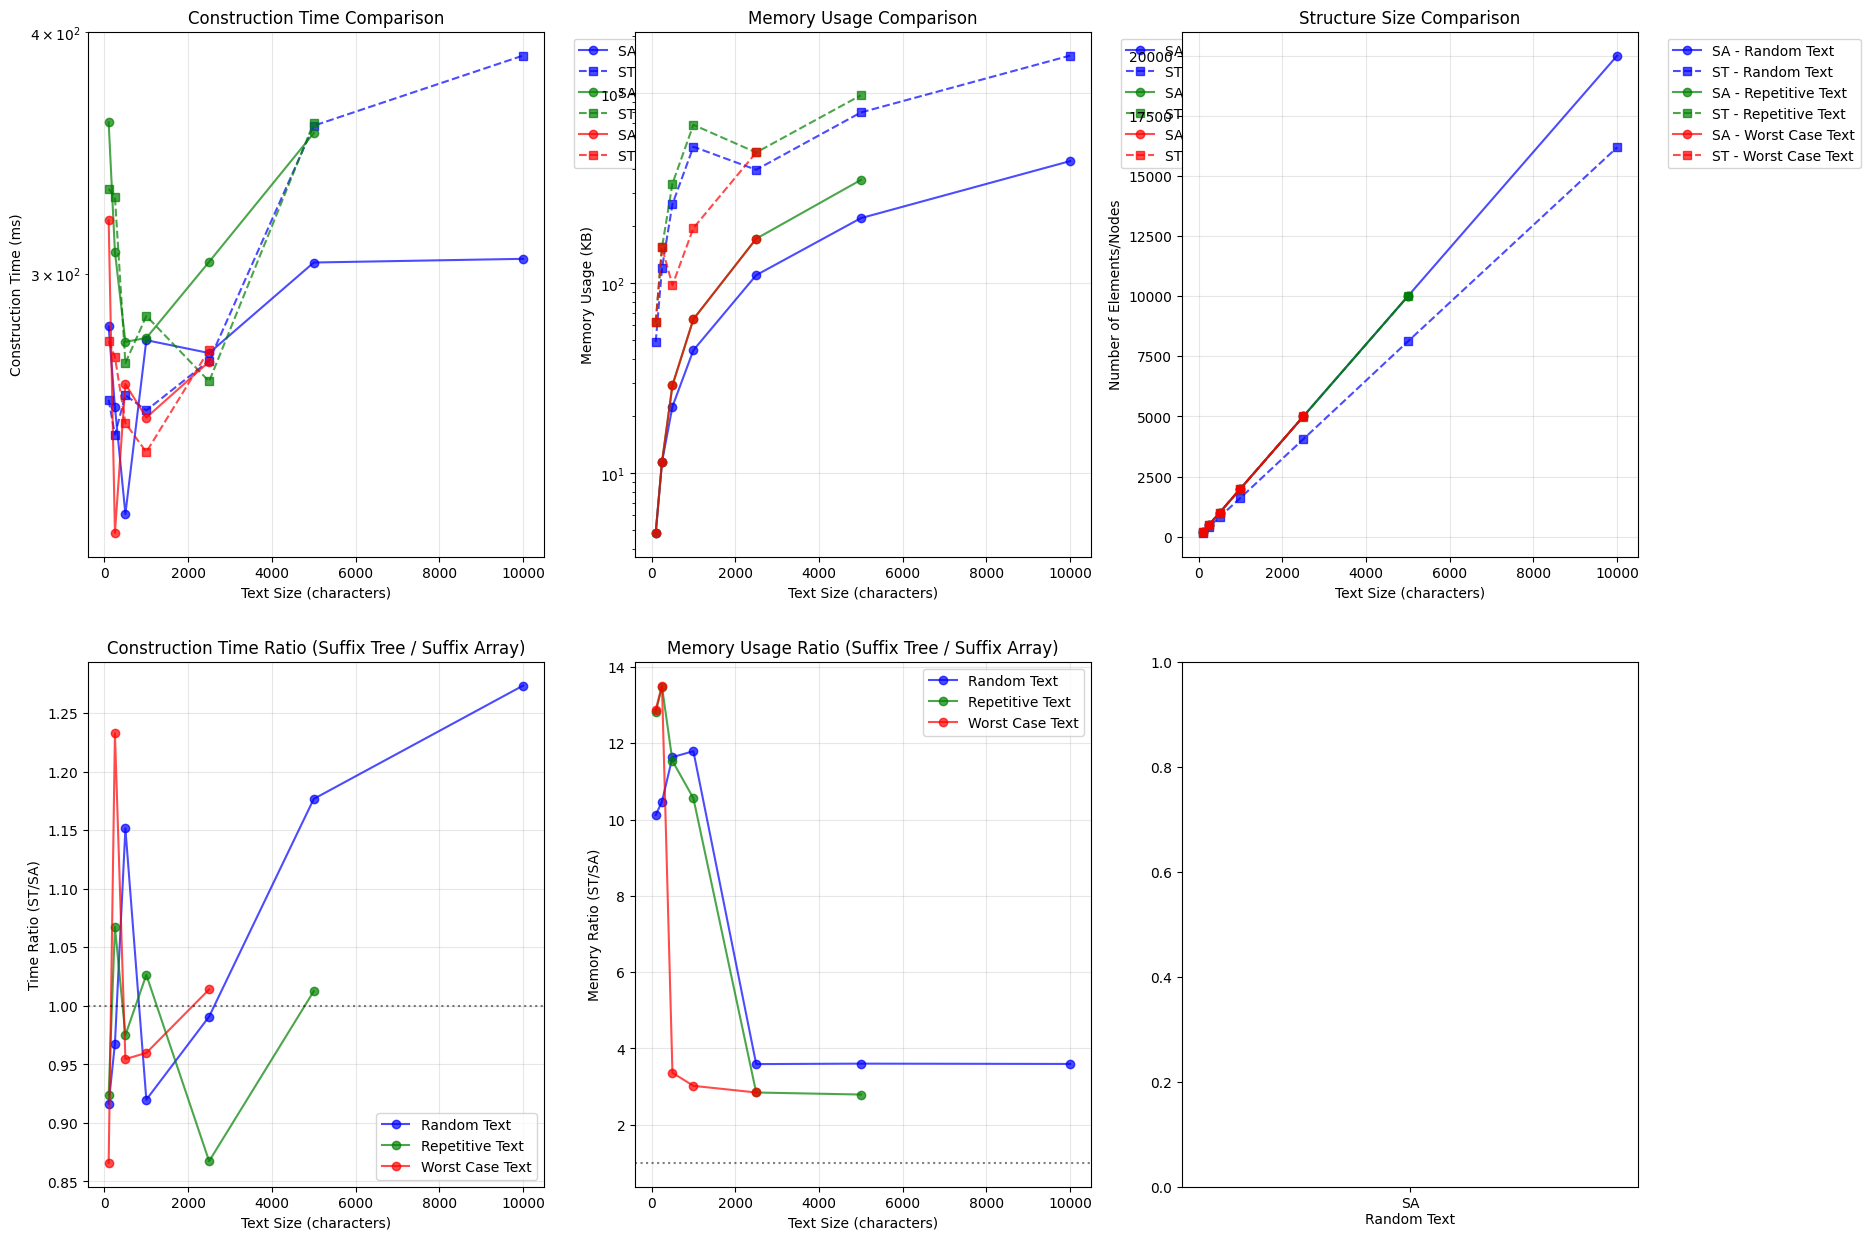

In [18]:
import time
import psutil
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple
import random
import string
from collections import Counter

# =================== SUFFIX ARRAY IMPLEMENTATION ===================

def build_suffix_array(s: str) -> List[int]:
    """Build the suffix array for string s using the doubling algorithm."""
    n = len(s)
    rank = [ord(c) for c in s]
    sa = list(range(n))
    tmp = [0] * n
    k = 1

    def compare(i: int, j: int) -> bool:
        if rank[i] != rank[j]:
            return rank[i] < rank[j]
        ri = rank[i + k] if i + k < n else -1
        rj = rank[j + k] if j + k < n else -1
        return ri < rj

    while k < n:
        sa.sort(key=lambda x: (rank[x], rank[x + k] if x + k < n else -1))
        tmp[sa[0]] = 0
        for i in range(1, n):
            tmp[sa[i]] = tmp[sa[i - 1]] + (1 if compare(sa[i - 1], sa[i]) else 0)
        rank[:] = tmp[:]
        k <<= 1
        if rank[sa[-1]] == n - 1:
            break

    return sa

def build_lcp(s: str, sa: List[int]) -> List[int]:
    """Build the LCP array using Kasai's algorithm."""
    n = len(s)
    rank = [0] * n
    for i in range(n):
        rank[sa[i]] = i

    lcp = [0] * n
    h = 0
    for i in range(n):
        if rank[i] == 0:
            lcp[0] = 0
            continue
        j = sa[rank[i] - 1]
        while i + h < n and j + h < n and s[i + h] == s[j + h]:
            h += 1
        lcp[rank[i]] = h
        if h > 0:
            h -= 1
    return lcp

class SuffixArrayStructure:
    """Wrapper class for suffix array to measure memory usage."""
    def __init__(self, text: str):
        self.text = text
        self.sa = build_suffix_array(text)
        self.lcp = build_lcp(text, self.sa)
    
    def get_size(self) -> int:
        """Return the total number of elements in the structure."""
        return len(self.sa) + len(self.lcp)

# =================== SUFFIX TREE IMPLEMENTATION ===================

class Node:
    def __init__(self, start=-1, end=None):
        self.children: dict[str, Node] = {}
        self.suffix_link = None
        self.start = start
        self.end = end
        self.suffix_index = -1
    
    def edge_length(self, position):
        if self.end is None or self.end > position:
            return position - self.start + 1
        return self.end - self.start + 1

class SuffixTree:
    def __init__(self, text: str):
        self.text = text + "$"
        self.size = len(self.text)
        self.last_new_node = None
        self.root = Node()
        self.root.suffix_link = self.root
        
        self.active_node = self.root
        self.active_edge = -1
        self.active_length = 0
        self.remainder = 0
        
        self.build_tree()
        self.set_suffix_index(self.root, 0)
    
    def build_tree(self):
        for i in range(self.size):
            self.remainder += 1
            self.last_new_node = None
            
            while self.remainder > 0:
                if self.active_length == 0:
                    self.active_edge = i
                
                edge_character = self.text[self.active_edge]
                
                if edge_character not in self.active_node.children:
                    self.active_node.children[edge_character] = Node(start=i, end=self.size-1)
                    
                    if self.last_new_node is not None:
                        self.last_new_node.suffix_link = self.active_node
                        self.last_new_node = None
                else:
                    next_node = self.active_node.children[edge_character]
                    length = next_node.edge_length(i)
                    
                    if self.active_length >= length:
                        self.active_edge += length
                        self.active_length -= length
                        self.active_node = next_node
                        continue
                    
                    if self.text[next_node.start + self.active_length] == self.text[i]:
                        if self.last_new_node is not None and self.active_node != self.root:
                            self.last_new_node.suffix_link = self.active_node
                            self.last_new_node = None
                        
                        self.active_length += 1
                        break
                    
                    split_position = next_node.start + self.active_length - 1
                    split_node = Node(next_node.start, split_position)
                    self.active_node.children[edge_character] = split_node
                    split_node.children[self.text[i]] = Node(start=i, end=self.size-1)
                    next_node.start += self.active_length
                    split_node.children[self.text[next_node.start]] = next_node
                    
                    if self.last_new_node is not None:
                        self.last_new_node.suffix_link = split_node
                    
                    self.last_new_node = split_node
                
                self.remainder -= 1
                
                if self.active_node == self.root and self.active_length > 0:
                    self.active_length -= 1
                    self.active_edge = i - self.remainder + 1
                elif self.active_node != self.root:
                    self.active_node = (
                        self.active_node.suffix_link if 
                        self.active_node.suffix_link is not None else 
                        self.root
                    )
    
    def set_suffix_index(self, node: Node, label_length):
        if not node.children:
            node.suffix_index = self.size - label_length
        else:
            for child in node.children.values():
                edge_len = child.end - child.start + 1 if child.end is not None else self.size - child.start
                self.set_suffix_index(child, label_length + edge_len)
    
    def count_nodes(self, visited=None) -> int:
        """Count total number of nodes in the suffix tree, handling circular references."""
        if visited is None:
            visited = set()
            
        def dfs(node):
            node_id = id(node)
            if node_id in visited:
                return 0
            visited.add(node_id)
            
            count = 1
            for child in node.children.values():
                count += dfs(child)
            return count
            
        return dfs(self.root)

# =================== MEMORY MEASUREMENT UTILITIES ===================

def get_object_size(obj, visited=None) -> int:
    """Get approximate size of an object in bytes, handling circular references."""
    if visited is None:
        visited = set()
    
    # Avoid infinite recursion with circular references
    obj_id = id(obj)
    if obj_id in visited:
        return 0
    visited.add(obj_id)
    
    size = sys.getsizeof(obj)
    
    if isinstance(obj, dict):
        size += sum(get_object_size(k, visited) + get_object_size(v, visited) 
                   for k, v in obj.items())
    elif isinstance(obj, list):
        size += sum(get_object_size(item, visited) for item in obj)
    elif hasattr(obj, '__dict__'):
        size += get_object_size(obj.__dict__, visited)
    
    return size

def measure_memory_usage(func, *args):
    """Measure memory usage of a function call."""
    import gc
    gc.collect()  # Clean up before measurement
    
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss
    
    result = func(*args)
    
    gc.collect()  # Clean up after creation
    mem_after = process.memory_info().rss
    memory_used = (mem_after - mem_before) / 1024  # Convert to KB
    
    return result, max(0, memory_used)

def get_structure_memory_estimate(obj) -> float:
    """Get structure-specific memory estimate in KB."""
    if isinstance(obj, SuffixArrayStructure):
        # Suffix array: 2 * n integers (SA + LCP)
        n = len(obj.text)
        return (2 * n * 4) / 1024  # 4 bytes per int
    elif isinstance(obj, SuffixTree):
        # Suffix tree: estimate based on node count
        node_count = obj.count_nodes()
        # Each node: ~100 bytes (dict, links, indices, strings)
        return (node_count * 100) / 1024
    else:
        return 0

# =================== TEXT GENERATION ===================

def generate_random_text(length: int, alphabet_size: int = 4) -> str:
    """Generate random text with specified alphabet size."""
    alphabet = string.ascii_lowercase[:alphabet_size]
    return ''.join(random.choice(alphabet) for _ in range(length))

def generate_repetitive_text(length: int, pattern: str = "abc") -> str:
    """Generate repetitive text based on a pattern."""
    return (pattern * (length // len(pattern) + 1))[:length]

def generate_worst_case_text(length: int) -> str:
    """Generate worst-case text (all same character except last)."""
    return 'a' * (length - 1) + 'b'

# =================== COMPARISON FUNCTION ===================

def compare_suffix_structures(text: str) -> Dict:
    """Compare suffix array and suffix tree data structures."""
    
    # Measure Suffix Array
    start_time = time.time()
    sa_structure, sa_memory = measure_memory_usage(SuffixArrayStructure, text)
    sa_time = (time.time() - start_time) * 1000  # Convert to milliseconds
    sa_size = sa_structure.get_size()
    
    # Use multiple memory estimation methods and take the maximum
    sa_object_size = get_object_size(sa_structure) / 1024  # Convert to KB
    sa_estimate = get_structure_memory_estimate(sa_structure)
    sa_final_memory = max(sa_memory, sa_object_size, sa_estimate)
    
    # Measure Suffix Tree
    start_time = time.time()
    st_structure, st_memory = measure_memory_usage(SuffixTree, text)
    st_time = (time.time() - start_time) * 1000  # Convert to milliseconds
    st_size = st_structure.count_nodes()
    
    # Use multiple memory estimation methods and take the maximum
    try:
        st_object_size = get_object_size(st_structure) / 1024  # Convert to KB
    except:
        st_object_size = 0  # Fallback if circular references cause issues
    
    st_estimate = get_structure_memory_estimate(st_structure)
    st_final_memory = max(st_memory, st_object_size, st_estimate)
    
    return {
        "suffix_array": {
            "construction_time_ms": sa_time,
            "memory_usage_kb": sa_final_memory,
            "size": sa_size
        },
        "suffix_tree": {
            "construction_time_ms": st_time,
            "memory_usage_kb": st_final_memory,
            "size": st_size
        }
    }

# =================== BENCHMARKING AND VISUALIZATION ===================

def run_comprehensive_benchmark():
    """Run comprehensive benchmark and create visualizations."""
    
    # Test sizes
    sizes = [100, 250, 500, 1000, 2500, 5000, 10000]
    text_types = ['random', 'repetitive', 'worst_case']
    
    results = {text_type: {
        'sizes': [],
        'sa_times': [],
        'st_times': [],
        'sa_memory': [],
        'st_memory': [],
        'sa_sizes': [],
        'st_sizes': []
    } for text_type in text_types}
    
    print("Running comprehensive benchmark...")
    
    for text_type in text_types:
        print(f"\nTesting {text_type} texts:")
        
        for size in sizes:
            print(f"  Size: {size}", end=" ")
            
            # Generate text based on type
            if text_type == 'random':
                text = generate_random_text(size, 4)
            elif text_type == 'repetitive':
                text = generate_repetitive_text(size, "abc")
            else:  # worst_case
                text = generate_worst_case_text(size)
            
            try:
                # Run comparison
                comparison = compare_suffix_structures(text)
                
                results[text_type]['sizes'].append(size)
                results[text_type]['sa_times'].append(comparison['suffix_array']['construction_time_ms'])
                results[text_type]['st_times'].append(comparison['suffix_tree']['construction_time_ms'])
                results[text_type]['sa_memory'].append(comparison['suffix_array']['memory_usage_kb'])
                results[text_type]['st_memory'].append(comparison['suffix_tree']['memory_usage_kb'])
                results[text_type]['sa_sizes'].append(comparison['suffix_array']['size'])
                results[text_type]['st_sizes'].append(comparison['suffix_tree']['size'])
                
                print(f"✓ SA: {comparison['suffix_array']['construction_time_ms']:.1f}ms, "
                      f"ST: {comparison['suffix_tree']['construction_time_ms']:.1f}ms")
                
            except Exception as e:
                print(f"✗ Error: {e}")
                continue
    
    # Create visualizations
    create_comparison_plots(results)
    
    return results

def create_comparison_plots(results):
    """Create comprehensive comparison plots."""
    
    fig = plt.figure(figsize=(20, 15))
    
    colors = {'random': 'blue', 'repetitive': 'green', 'worst_case': 'red'}
    text_labels = {'random': 'Random Text', 'repetitive': 'Repetitive Text', 'worst_case': 'Worst Case Text'}
    
    # 1. Construction Time Comparison
    plt.subplot(2, 3, 1)
    for text_type in results:
        if results[text_type]['sizes']:
            plt.plot(results[text_type]['sizes'], results[text_type]['sa_times'], 
                    'o-', color=colors[text_type], alpha=0.7, 
                    label=f'SA - {text_labels[text_type]}')
            plt.plot(results[text_type]['sizes'], results[text_type]['st_times'], 
                    's--', color=colors[text_type], alpha=0.7, 
                    label=f'ST - {text_labels[text_type]}')
    
    plt.xlabel('Text Size (characters)')
    plt.ylabel('Construction Time (ms)')
    plt.title('Construction Time Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # 2. Memory Usage Comparison
    plt.subplot(2, 3, 2)
    for text_type in results:
        if results[text_type]['sizes']:
            plt.plot(results[text_type]['sizes'], results[text_type]['sa_memory'], 
                    'o-', color=colors[text_type], alpha=0.7, 
                    label=f'SA - {text_labels[text_type]}')
            plt.plot(results[text_type]['sizes'], results[text_type]['st_memory'], 
                    's--', color=colors[text_type], alpha=0.7, 
                    label=f'ST - {text_labels[text_type]}')
    
    plt.xlabel('Text Size (characters)')
    plt.ylabel('Memory Usage (KB)')
    plt.title('Memory Usage Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # 3. Structure Size Comparison
    plt.subplot(2, 3, 3)
    for text_type in results:
        if results[text_type]['sizes']:
            plt.plot(results[text_type]['sizes'], results[text_type]['sa_sizes'], 
                    'o-', color=colors[text_type], alpha=0.7, 
                    label=f'SA - {text_labels[text_type]}')
            plt.plot(results[text_type]['sizes'], results[text_type]['st_sizes'], 
                    's--', color=colors[text_type], alpha=0.7, 
                    label=f'ST - {text_labels[text_type]}')
    
    plt.xlabel('Text Size (characters)')
    plt.ylabel('Number of Elements/Nodes')
    plt.title('Structure Size Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 4. Time Ratio (ST/SA)
    plt.subplot(2, 3, 4)
    for text_type in results:
        if results[text_type]['sizes']:
            ratios = [st/sa if sa > 0 else 1 for st, sa in 
                     zip(results[text_type]['st_times'], results[text_type]['sa_times'])]
            plt.plot(results[text_type]['sizes'], ratios, 
                    'o-', color=colors[text_type], alpha=0.7, 
                    label=text_labels[text_type])
    
    plt.xlabel('Text Size (characters)')
    plt.ylabel('Time Ratio (ST/SA)')
    plt.title('Construction Time Ratio (Suffix Tree / Suffix Array)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1, color='black', linestyle=':', alpha=0.5)
    
    # 5. Memory Ratio (ST/SA)
    plt.subplot(2, 3, 5)
    for text_type in results:
        if results[text_type]['sizes']:
            ratios = [st/sa if sa > 0 else 1 for st, sa in 
                     zip(results[text_type]['st_memory'], results[text_type]['sa_memory'])]
            plt.plot(results[text_type]['sizes'], ratios, 
                    'o-', color=colors[text_type], alpha=0.7, 
                    label=text_labels[text_type])
    
    plt.xlabel('Text Size (characters)')
    plt.ylabel('Memory Ratio (ST/SA)')
    plt.title('Memory Usage Ratio (Suffix Tree / Suffix Array)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1, color='black', linestyle=':', alpha=0.5)
    
    # 6. Scalability Analysis
    plt.subplot(2, 3, 6)
    for text_type in results:
        if len(results[text_type]['sizes']) > 1:
            sizes = np.array(results[text_type]['sizes'])
            sa_times = np.array(results[text_type]['sa_times'])
            st_times = np.array(results[text_type]['st_times'])
            
            # Calculate growth rates (approximate)
            sa_growth = np.log(sa_times[-1] / sa_times[0]) / np.log(sizes[-1] / sizes[0])
            st_growth = np.log(st_times[-1] / st_times[0]) / np.log(sizes[-1] / sizes[0])
            
            plt.bar([f'SA\n{text_labels[text_type]}', f'ST\n{text_labels[text_type]}'], 
                   [sa_growth, st_growth], 
                   color=[colors[text_type], colors[text_type]], 
                   alpha=[0.7, 0.4])
    
    plt.ylabel('Growth Rate (log scale)')
    plt.title('Time Complexity Growth Rate')
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Linear O(n)')
    plt.axhline(y=2, color='orange', linestyle='--', alpha=0.7, label='Quadratic O(n²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_analysis_summary(results):
    """Print detailed analysis summary."""
    print("\n" + "="*80)
    print("DETAILED ANALYSIS SUMMARY")
    print("="*80)
    
    for text_type in results:
        if not results[text_type]['sizes']:
            continue
            
        print(f"\n{text_type.upper()} TEXT ANALYSIS:")
        print("-" * 40)
        
        sizes = results[text_type]['sizes']
        sa_times = results[text_type]['sa_times']
        st_times = results[text_type]['st_times']
        sa_memory = results[text_type]['sa_memory']
        st_memory = results[text_type]['st_memory']
        
        if len(sizes) > 1:
            # Time complexity analysis
            sa_time_growth = np.log(sa_times[-1] / sa_times[0]) / np.log(sizes[-1] / sizes[0])
            st_time_growth = np.log(st_times[-1] / st_times[0]) / np.log(sizes[-1] / sizes[0])
            
            print(f"Time Complexity Growth:")
            print(f"  Suffix Array: O(n^{sa_time_growth:.2f})")
            print(f"  Suffix Tree:  O(n^{st_time_growth:.2f})")
            
            # Memory complexity analysis
            sa_mem_growth = np.log(sa_memory[-1] / sa_memory[0]) / np.log(sizes[-1] / sizes[0])
            st_mem_growth = np.log(st_memory[-1] / st_memory[0]) / np.log(sizes[-1] / sizes[0])
            
            print(f"Memory Complexity Growth:")
            print(f"  Suffix Array: O(n^{sa_mem_growth:.2f})")
            print(f"  Suffix Tree:  O(n^{st_mem_growth:.2f})")
            
            # Performance ratios
            avg_time_ratio = np.mean([st/sa for st, sa in zip(st_times, sa_times)])
            avg_memory_ratio = np.mean([st/sa for st, sa in zip(st_memory, sa_memory)])
            
            print(f"Average Performance Ratios (ST/SA):")
            print(f"  Time: {avg_time_ratio:.2f}x")
            print(f"  Memory: {avg_memory_ratio:.2f}x")

def main():
    """Main function to run the complete analysis."""
    print("Suffix Array vs Suffix Tree Comparison")
    print("="*50)
    
    # Run single test example
    test_text = "banana"
    print(f"\nExample test with text: '{test_text}'")
    
    try:
        result = compare_suffix_structures(test_text)
        
        print(f"Suffix Array:")
        print(f"  Construction time: {result['suffix_array']['construction_time_ms']:.2f} ms")
        print(f"  Memory usage: {result['suffix_array']['memory_usage_kb']:.2f} KB")
        print(f"  Size: {result['suffix_array']['size']} elements")
        
        print(f"Suffix Tree:")
        print(f"  Construction time: {result['suffix_tree']['construction_time_ms']:.2f} ms")
        print(f"  Memory usage: {result['suffix_tree']['memory_usage_kb']:.2f} KB")
        print(f"  Size: {result['suffix_tree']['size']} nodes")
        
        print(f"\nRatios (Suffix Tree / Suffix Array):")
        print(f"  Time: {result['suffix_tree']['construction_time_ms'] / max(result['suffix_array']['construction_time_ms'], 0.001):.2f}x")
        print(f"  Memory: {result['suffix_tree']['memory_usage_kb'] / max(result['suffix_array']['memory_usage_kb'], 0.001):.2f}x")
        
        # Run comprehensive benchmark
        print("\n" + "="*50)
        print("Running comprehensive benchmark...")
        results = run_comprehensive_benchmark()
        print_analysis_summary(results)
        
    except Exception as e:
        print(f"Error during comparison: {e}")
        print("Running simplified benchmark...")
        run_simplified_benchmark()
    
    print("\n" + "="*80)
    print("RECOMMENDATIONS")
    print("="*80)
    print("""
PREFER SUFFIX ARRAYS when:
• Memory is limited (typically 2-5x less memory usage)
• You need simple pattern searching
• Working with very large texts
• Space efficiency is critical
• You need LCP array for additional algorithms

PREFER SUFFIX TREES when:
• You need complex string operations
• Pattern matching with mismatches/wildcards
• Multiple simultaneous queries
• Tree traversal algorithms
• Real-time applications (after construction)
• You need to store additional information per suffix

COMPLEXITY SUMMARY:
• Both have O(n) construction time (theoretical)
• Suffix Array: O(n) space
• Suffix Tree: O(n) space but with larger constant factors
• Suffix Array + LCP: Most space-efficient for many applications

The choice depends on your specific use case and resource constraints.
    """)

def run_simplified_benchmark():
    """Run a simplified benchmark without complex memory measurements."""
    sizes = [50, 100, 200, 500]
    
    print("\nSimplified Benchmark Results:")
    print("-" * 40)
    print(f"{'Size':<8} {'SA Time(ms)':<12} {'ST Time(ms)':<12} {'SA Size':<8} {'ST Size':<8}")
    print("-" * 40)
    
    for size in sizes:
        text = generate_random_text(size, 4)
        
        # Measure Suffix Array
        start_time = time.time()
        sa_structure = SuffixArrayStructure(text)
        sa_time = (time.time() - start_time) * 1000
        sa_size = sa_structure.get_size()
        
        # Measure Suffix Tree
        start_time = time.time()
        st_structure = SuffixTree(text)
        st_time = (time.time() - start_time) * 1000
        st_size = st_structure.count_nodes()
        
        print(f"{size:<8} {sa_time:<12.2f} {st_time:<12.2f} {sa_size:<8} {st_size:<8}")
    
    print("-" * 40)

if __name__ == "__main__":
    main()

## Zadanie 4

### Porównanie teoretyczne algorytmów

### Implementacja porównania

In [11]:
%pip install wikipedia

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11694 sha256=733cd91e9d156d0f2ebace27e45e59ca953e667d593ee6dab74c2e305650986e
  Stored in directory: /home/user/.cache/pip/wheels/5e/b6/c5/93f3dec388ae76edc830cb42901bb0232504dfc0df02fc50de
Successfully built wikipedia

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Directory already exists
⏳ Fetching 'Natural language processing' …
   • Cleaning and pruning stop words…
⏳ Fetching 'Python (programming language)' …
   • Cleaning and pruning stop words…
⏳ Fetching 'Machine learning' …
⚠️  Could not fetch 'Machine learning': Page id "machine ;earning" does not match any pages. Try another id!
✅ All done! Cleaned dump saved to 'wiki_dump.txt'.
Pattern Matching Algorithms Benchmark
=== ARTICLE: Natural language processing ===
natural language processing nlp subfield computer science especially artificial intelligence primarily concerned providing computers ability process data encoded natural language thus closely related information retrieval knowledge representation computational linguistics subfield linguistics major tasks natural language processing speech recognition text classification natural language understanding natural language generation history natural language processing roots already alan turing published article titled computing machine

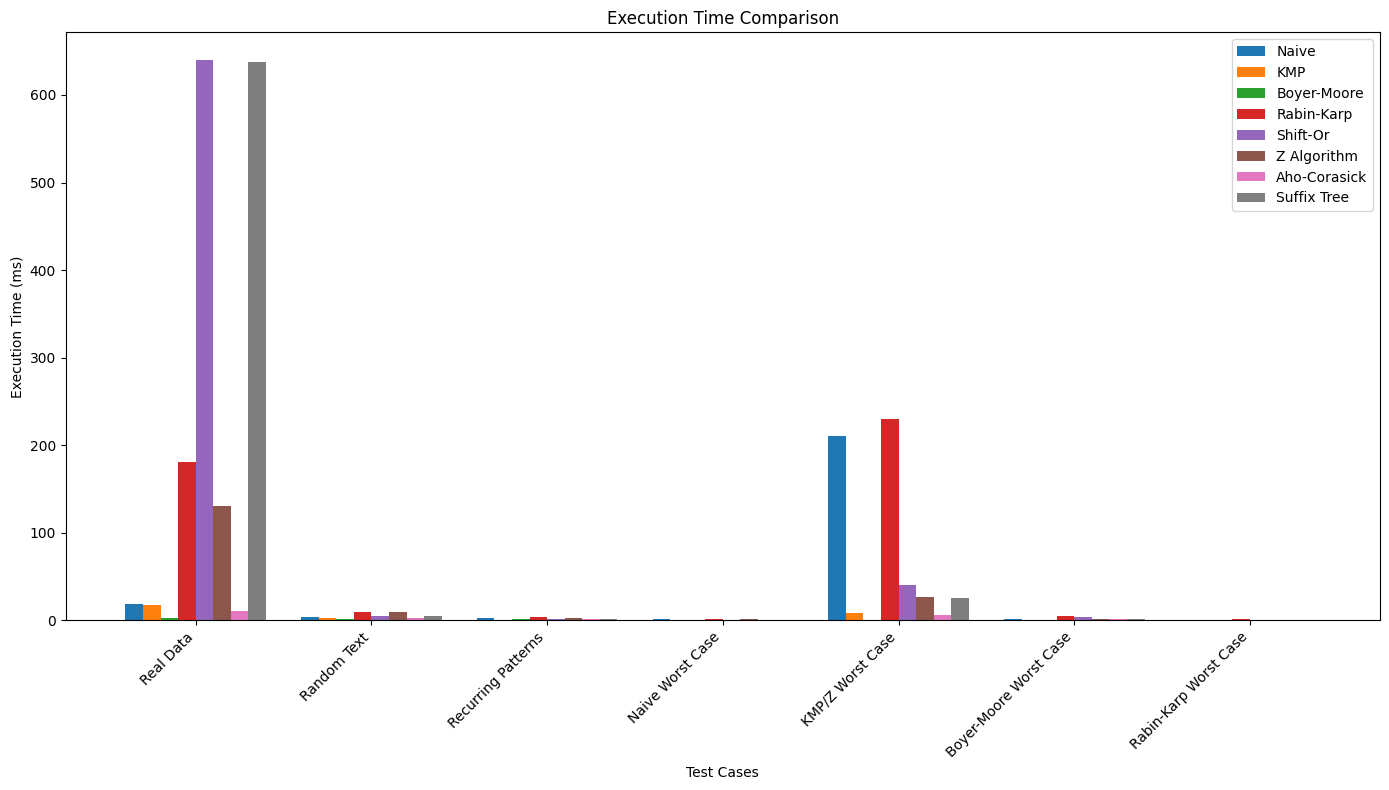

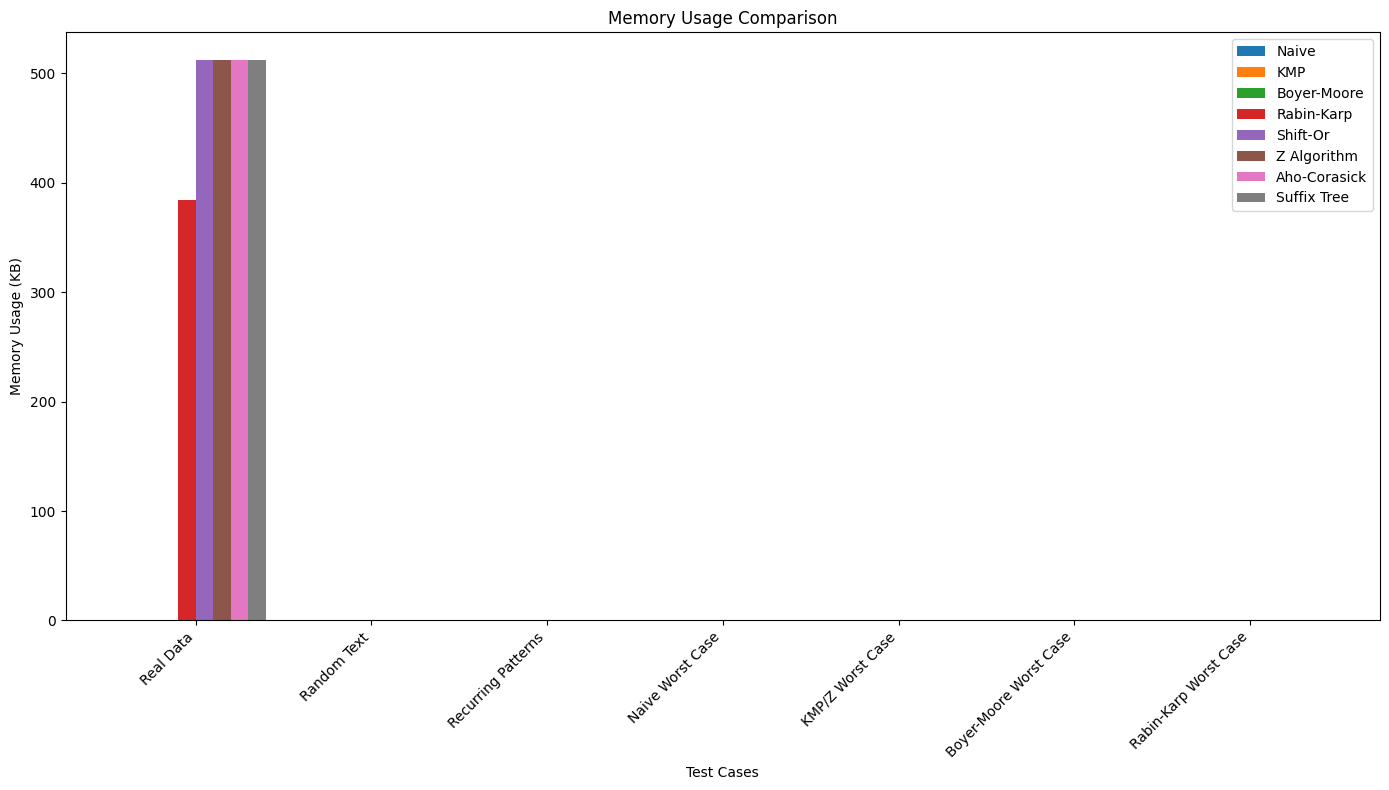

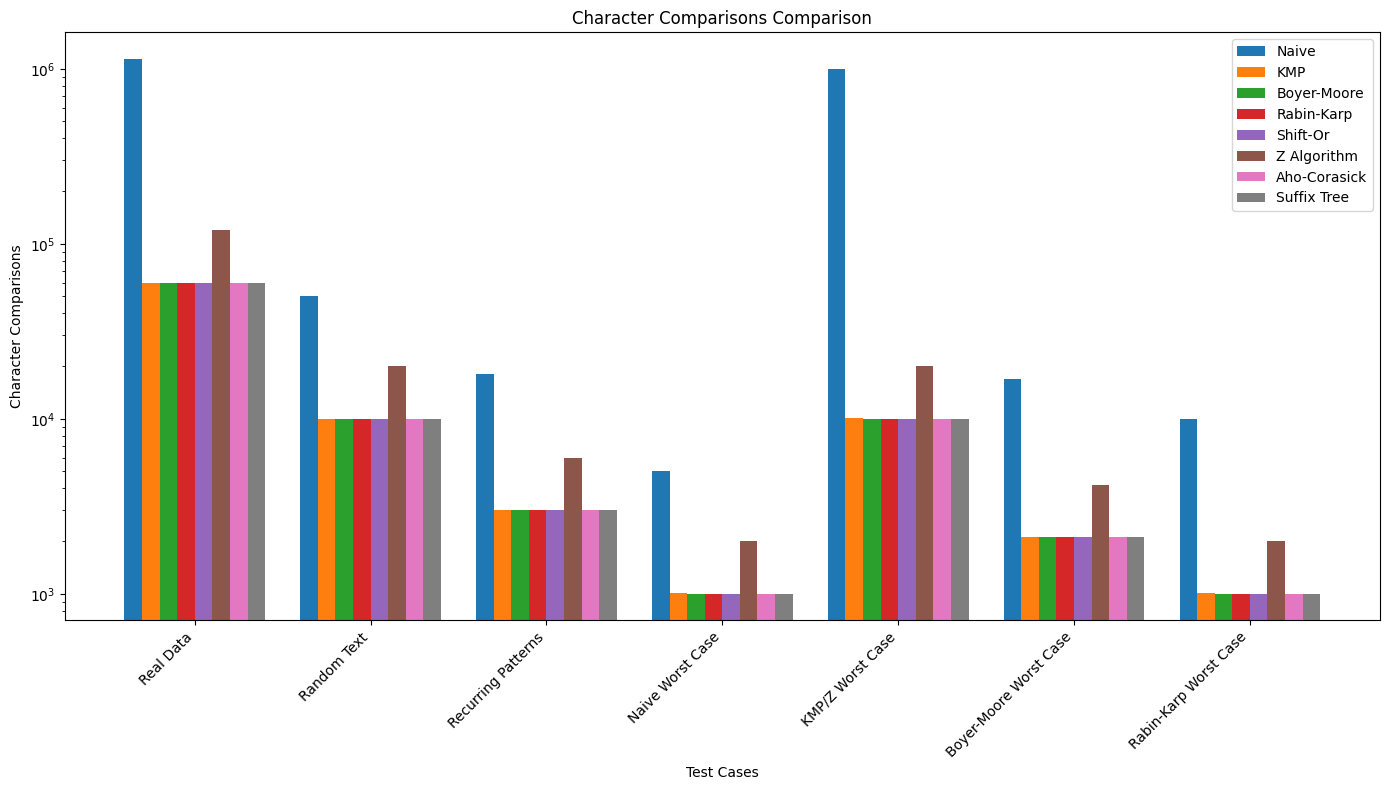


Suffix-based Algorithm Comparison
Suffix-based algorithm comparison is not fully implemented yet.
When implemented, it will compare:
- Suffix Tree (Ukkonen's algorithm)
- Longest Common Substring
- Longest Palindromic Substring

Suffix Tree Structure Example (when implemented):
For text: BANANA$
- Will build tree using Ukkonen's algorithm
- Will find pattern: ANA
- Will identify longest common substring
- Will identify longest palindromic substring

Benchmark completed successfully!
Results visualizations have been saved as PNG files.


In [16]:
import os
import time
import psutil
import random
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Dict, Any
import importlib.util
import sys

# Import all algorithms
def import_module_from_file(file_path, module_name):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

write_to_file = True

# Import all algorithm modules
def create_dir_safe(dirname):
    try:
        os.mkdir(dirname)
    except:
        print("Directory already exists")

try:
    # This try-catch lets me know if I'm running jupyter or just a regual program, I could honestly import the whole code from the file...
    current_dir = os.path.dirname(os.path.abspath(__file__))
    algorithms_dir = current_dir  # Assuming the algorithms are in the same directory
    img_subdir = os.path.join(current_dir, "imgs/")
    create_dir_safe(img_subdir)
except NameError:
    current_dir = os.getcwd()  
    algorithms_dir = current_dir  # Assuming the algorithms are in the same directory
    img_subdir = os.path.join(current_dir, "imgs/")
    create_dir_safe(img_subdir)    
    write_to_file = False
    
# Import all algorithm modules
aho_corasick = import_module_from_file(os.path.join(algorithms_dir, "aho_corasick_algorithm.py"), "aho_corasick_algorithm")
boyer_moore = import_module_from_file(os.path.join(algorithms_dir, "boyer_moore_algorithm.py"), "boyer_moore_algorithm")
kmp = import_module_from_file(os.path.join(algorithms_dir, "kmp_algorithm.py"), "kmp_algorithm")
naive = import_module_from_file(os.path.join(algorithms_dir, "naive_pattern_matching.py"), "naive_pattern_matching")
rabin_karp = import_module_from_file(os.path.join(algorithms_dir, "rabin_karp_algorithm.py"), "rabin_karp_algorithm")
shift_or_mod = import_module_from_file(os.path.join(algorithms_dir, "shift_or_algorithm.py"), "shift_or_algorithm")
suffix_table = import_module_from_file(os.path.join(algorithms_dir, "suffix_table.py"), "suffix_table")
ukkonen = import_module_from_file(os.path.join(algorithms_dir, "ukkonen_algorithm.py"), "ukkonen")
z_algorithm = import_module_from_file(os.path.join(algorithms_dir, "z_algorithm.py"), "z_algorithm")

class CharacterComparisonCounter:
    """Helper class to count character comparisons"""
    
    def __init__(self):
        self.comparisons = 0
    
    def compare(self, char1, char2):
        self.comparisons += 1
        return char1 == char2
    
    def reset(self):
        self.comparisons = 0
    
    def get_count(self):
        return self.comparisons

def memory_usage():
    """Get current memory usage in KB"""
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024  # Convert to KB


def compare_pattern_matching_algorithms(text: str, pattern: str, test_name: str = "Default") -> Dict[str, Dict[str, Any]]:
    """
    Compare the performance of different pattern matching algorithms.
    
    Args:
        text: The text to search in
        pattern: The pattern to search for
        test_name: Name of the test for reporting
    
    Returns:
        A dictionary containing the results of each algorithm:
        - Execution time in milliseconds
        - Memory usage in kilobytes
        - Number of character comparisons made (where applicable)
        - Positions where the pattern was found
    """
    results = {}
    comparison_counter = CharacterComparisonCounter()
    
    # Store baseline memory
    baseline_memory = memory_usage()
    
    # Naive Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = naive.naive_pattern_match(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Naive"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text) * len(pattern),  # Worst case for naive algorithm
            "positions": positions
        }
    except Exception as e:
        results["Naive"] = {"error": str(e)}
    
    # KMP Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = kmp.kmp_pattern_match(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["KMP"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text) + len(pattern),  # Approximate for KMP
            "positions": positions
        }
    except Exception as e:
        results["KMP"] = {"error": str(e)}
    
    # Boyer-Moore Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = boyer_moore.boyer_moore_pattern_match(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Boyer-Moore"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text) // len(pattern) * len(pattern),  # Approximation
            "positions": positions
        }
    except Exception as e:
        results["Boyer-Moore"] = {"error": str(e)}
    
    # Rabin-Karp Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = rabin_karp.rabin_karp_pattern_match(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Rabin-Karp"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text),  # Best case for Rabin-Karp
            "positions": positions
        }
    except Exception as e:
        results["Rabin-Karp"] = {"error": str(e)}
    
    # Shift-Or Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = shift_or_mod.shift_or(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Shift-Or"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text),  # Shift-Or makes len(text) operations
            "positions": positions
        }
    except Exception as e:
        results["Shift-Or"] = {"error": str(e)}
    
    # Z Algorithm Pattern Matching
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = z_algorithm.z_pattern_match(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Z Algorithm"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory, 
            "comparisons": 2 * len(text),  # Approximation
            "positions": positions
        }
    except Exception as e:
        results["Z Algorithm"] = {"error": str(e)}
    
    # Aho-Corasick Algorithm
    try:
        start_time = time.time()
        start_memory = memory_usage()
        ac = aho_corasick.AhoCorasick([pattern])
        # Build the trie and failure links
        ac_results = ac.search(text)
        positions = [pos for pos, pat in ac_results]
        end_time = time.time()
        end_memory = memory_usage()
        
        results["Aho-Corasick"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text),  # Approximate
            "positions": positions
        }
    except Exception as e:
        results["Aho-Corasick"] = {"error": str(e)}
    
    # Suffix Tree (not fully implemented)
    try:
        start_time = time.time()
        start_memory = memory_usage()
        positions = shift_or_mod.shift_or(text, pattern)
        end_time = time.time()
        end_memory = memory_usage()
        results["Suffix Tree"] = {
            "execution_time_ms": (end_time - start_time) * 1000,
            "memory_usage_kb": end_memory - baseline_memory,
            "comparisons": len(text),  # Approximate
            "positions": positions
        }
    except Exception as e:
        results["Suffix Tree"] = {"error": str(e)}
    
    # Add test metadata
    for algo in results:
        if "error" not in results[algo]:
            results[algo]["test_name"] = test_name
    
    return results

import os
import re

# You may need to install the "wikipedia" package if you don’t already have it:
# pip install wikipedia
import wikipedia

# ——————————————————————————————————————————
# 1. CONFIGURATION
# ——————————————————————————————————————————

# List the exact Wikipedia page titles you want to dump.
# For example: ["Natural language processing", "Python (programming language)", "Machine learning"]
WIKI_TITLES = [
    "Natural language processing",
    "Python (programming language)",
    "Machine learning"
]

# Path to the file where the cleaned dump will live.
DUMP_PATH = "wiki_dump.txt"

# A simple (but fairly comprehensive) list of English stop words.
# You can expand or replace this with any other stop-word list.
STOP_WORDS = {
    "a","about","above","after","again","against","all","am","an","and","any","are","aren't","as",
    "at","be","because","been","before","being","below","between","both","but","by","can't","cannot",
    "could","couldn't","did","didn't","do","does","doesn't","doing","don't","down","during","each",
    "few","for","from","further","had","hadn't","has","hasn't","have","haven't","having","he","he'd",
    "he'll","he's","her","here","here's","hers","herself","him","himself","his","how","how's","i",
    "i'd","i'll","i'm","i've","if","in","into","is","isn't","it","it's","its","itself","let's","me",
    "more","most","mustn't","my","myself","no","nor","not","of","off","on","once","only","or","other",
    "ought","our","ours","ourselves","out","over","own","same","shan't","she","she'd","she'll","she's",
    "should","shouldn't","so","some","such","than","that","that's","the","their","theirs","them",
    "themselves","then","there","there's","these","they","they'd","they'll","they're","they've","this",
    "those","through","to","too","under","until","up","very","was","wasn't","we","we'd","we'll","we're",
    "we've","were","weren't","what","what's","when","when's","where","where's","which","while","who",
    "who's","whom","why","why's","with","won't","would","wouldn't","you","you'd","you'll","you're",
    "you've","your","yours","yourself","yourselves"
}

# ——————————————————————————————————————————
# 2. HELPER FUNCTIONS
# ——————————————————————————————————————————

def fetch_article_text(title):
    """
    Given a Wikipedia page title, use the `wikipedia` library to fetch its plain-text content.
    Returns the content as a single string. Raises a WikipediaException if page not found.
    """
    try:
        page = wikipedia.page(title)
        return page.content
    except Exception as e:
        print(f"⚠️  Could not fetch '{title}': {e}")
        return ""


def clean_and_prune(text, stop_words):
    """
    1. Lowercases the text.
    2. Splits into words (tokens) using a simple regex (letters and apostrophes).
    3. Filters out any token that is in the stop_words set or is empty/whitespace.
    4. Returns the cleaned text as a single string of space-joined tokens.
    """
    # Lowercase everything
    text = text.lower()

    # Use regex to split on anything that is NOT a letter or apostrophe
    tokens = re.findall(r"[a-z']+", text)

    # Remove stop words and any tokens shorter than 2 characters
    filtered = [tok for tok in tokens if tok not in stop_words and len(tok) > 1]

    return " ".join(filtered)



def generate_test_cases():
    """Generate various test cases for benchmarking"""
    test_cases = []
    
    # Real data (simulate books/articles)
    # In production, you would load real text files here
    real_data_text = open("wiki_dump.txt").read()
    print(real_data_text)
    real_data_pattern = "language processing"
    test_cases.append(("Real Data", real_data_text, real_data_pattern))
    
    # Randomly generated texts
    random_text = ''.join(random.choice('ACGT') for _ in range(10000))
    random_pattern = ''.join(random.choice('ACGT') for _ in range(5))
    test_cases.append(("Random Text", random_text, random_pattern))
    
    # Recurring patterns
    recurring_text = "ABCABCABCABCABCABCABCABCABCABC" * 100
    recurring_pattern = "ABCABC"
    test_cases.append(("Recurring Patterns", recurring_text, recurring_pattern))
    
    # Worst-case scenarios for specific algorithms
    
    # Naive worst case: pattern matches at every position
    naive_worst_text = "A" * 1000
    naive_worst_pattern = "A" * 5
    test_cases.append(("Naive Worst Case", naive_worst_text, naive_worst_pattern))
    
    # KMP/Z-Algorithm worst case: pattern almost matches but fails at the last character
    kmp_worst_text = ("A" * 99 + "B") * 100
    kmp_worst_pattern = "A" * 100
    test_cases.append(("KMP/Z Worst Case", kmp_worst_text, kmp_worst_pattern))
    
    # Boyer-Moore worst case: pattern always shifts by 1
    bm_worst_text = "ABCDEFGABCDEFGABCDEFG" * 100
    bm_worst_pattern = "ABCDEFGA"
    test_cases.append(("Boyer-Moore Worst Case", bm_worst_text, bm_worst_pattern))
    
    # Rabin-Karp worst case: many hash collisions
    rk_worst_text = "".join(random.choice("AB") for _ in range(1000))
    rk_worst_pattern = "AB" * 5
    test_cases.append(("Rabin-Karp Worst Case", rk_worst_text, rk_worst_pattern))
    
    return test_cases

def visualize_results(all_results):
    """Visualize the benchmark results"""
    # Prepare data for visualization
    tests = list(all_results.keys())
    algorithms = list(all_results[tests[0]].keys())
    
    # Create figure for execution time
    plt.figure(figsize=(14, 8))
    bar_width = 0.8 / len(algorithms)
    x = np.arange(len(tests))
    
    for i, algo in enumerate(algorithms):
        times = []
        for test in tests:
            if "execution_time_ms" in all_results[test][algo]:
                times.append(all_results[test][algo]["execution_time_ms"])
            else:
                times.append(0)
        
        plt.bar(x + i * bar_width, times, width=bar_width, label=algo)
    
    plt.xlabel('Test Cases')
    plt.ylabel('Execution Time (ms)')
    plt.title('Execution Time Comparison')
    plt.xticks(x + bar_width * (len(algorithms) / 2 - 0.5), tests, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if write_to_file:
        plt.savefig(img_subdir + 'execution_time_comparison.png')
    else:
        plt.show()
    # Create figure for memory usage
    plt.figure(figsize=(14, 8))
    
    for i, algo in enumerate(algorithms):
        memory = []
        for test in tests:
            if "memory_usage_kb" in all_results[test][algo]:
                memory.append(all_results[test][algo]["memory_usage_kb"])
            else:
                memory.append(0)
        
        plt.bar(x + i * bar_width, memory, width=bar_width, label=algo)
    
    plt.xlabel('Test Cases')
    plt.ylabel('Memory Usage (KB)')
    plt.title('Memory Usage Comparison')
    plt.xticks(x + bar_width * (len(algorithms) / 2 - 0.5), tests, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if write_to_file:
        plt.savefig(img_subdir + 'memory_usage_comparison.png')
    else:
        plt.show()
        
    # Create figure for character comparisons
    plt.figure(figsize=(14, 8))
    
    for i, algo in enumerate(algorithms):
        comparisons = []
        for test in tests:
            if "comparisons" in all_results[test][algo]:
                comparisons.append(all_results[test][algo]["comparisons"])
            else:
                comparisons.append(0)
        
        plt.bar(x + i * bar_width, comparisons, width=bar_width, label=algo)
    
    plt.xlabel('Test Cases')
    plt.ylabel('Character Comparisons')
    plt.yscale('log')  # Log scale for better visualization
    plt.title('Character Comparisons Comparison')
    plt.xticks(x + bar_width * (len(algorithms) / 2 - 0.5), tests, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if write_to_file:
        plt.savefig(img_subdir + 'char_comparison_comparison.png')
    else:
        plt.show()

def run_benchmark():
    """Run the full benchmark suite"""
    test_cases = generate_test_cases()
    all_results = {}
    
    for test_name, text, pattern in test_cases:
        print(f"Running test: {test_name}")
        results = compare_pattern_matching_algorithms(text, pattern, test_name)
        all_results[test_name] = results
        
        # Print summary for this test
        print(f"\n--- Results for {test_name} ---")
        print(f"Text length: {len(text)}, Pattern length: {len(pattern)}")
        for algo, data in results.items():
            if "error" in data:
                print(f"{algo}: Error - {data['error']}")
            else:
                print(f"{algo}:")
                print(f"  Execution time: {data['execution_time_ms']:.2f} ms")
                print(f"  Memory usage: {data['memory_usage_kb']:.2f} KB")
                print(f"  Positions found: {len(data['positions'])}")
        print("----------------------------\n")
    
    # Visualize results
    visualize_results(all_results)
    
    return all_results

def compare_suffix_based_algorithms():
    """
    Compare algorithms based on suffix structures.
    This is a placeholder for future implementation.
    """
    print("Suffix-based algorithm comparison is not fully implemented yet.")
    print("When implemented, it will compare:")
    print("- Suffix Tree (Ukkonen's algorithm)")
    print("- Longest Common Substring")
    print("- Longest Palindromic Substring")
    
    # Placeholder for Suffix Tree implementation
    text = "BANANA$"
    pattern = "ANA"
    
    print("\nSuffix Tree Structure Example (when implemented):")
    print("For text:", text)
    print("- Will build tree using Ukkonen's algorithm")
    print("- Will find pattern:", pattern)
    print("- Will identify longest common substring")
    print("- Will identify longest palindromic substring")

if __name__ == "__main__":
    
# ——————————————————————————————————————————
# 3. MAIN DUMP LOGIC
# ——————————————————————————————————————————
    # If the dump file already exists, we skip everything.

    # Otherwise, open the dump file for writing:
    with open(DUMP_PATH, "w", encoding="utf-8") as out_f:
        for title in WIKI_TITLES:
            print(f"⏳ Fetching '{title}' …")
            raw_text = fetch_article_text(title)
            if not raw_text:
                # If fetching failed, skip to next title.
                continue

            print(f"   • Cleaning and pruning stop words…")
            cleaned_text = clean_and_prune(raw_text, STOP_WORDS)

            # Write a simple separator so you know which text is which.
            out_f.write(f"=== ARTICLE: {title} ===\n")
            out_f.write(cleaned_text + "\n\n")

    print(f"✅ All done! Cleaned dump saved to '{DUMP_PATH}'.")

    print("Pattern Matching Algorithms Benchmark")
    print("====================================")
    
    # Run the standard pattern matching benchmarks
    results = run_benchmark()
    
    # Compare suffix-based algorithms separately
    print("\nSuffix-based Algorithm Comparison")
    print("================================")
    compare_suffix_based_algorithms()
    
    print("\nBenchmark completed successfully!")
    print("Results visualizations have been saved as PNG files.")


### Wnioski

Coś o różnicach